lets do the eda analysis to know the data properly so lets import the required libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

lets load the csv file

In [2]:
df = pd.read_csv("/content/mortgage_covenant_data.csv")
df.head()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


lets check the dataset size

In [3]:
df.shape

(100931, 14)

lets see the column names

In [4]:
df.columns

Index(['activity_year', 'census_tract', 'derived_race', 'action_taken',
       'loan_amount', 'property_value', 'income', 'interest_rate',
       'tract_minority_population_percent', 'tract_to_msa_income_percentage',
       'denial_reason-1', 'covenant_count', 'was_approved',
       'covenant_density'],
      dtype='object')

lets see the datatypes of the column names we got

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

lets see the dataset summary statistics

In [6]:
df.describe()

,activity_year,census_tract,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count
count,100931.0,9.991500e+04,100931.000000,1.009310e+05,8.349100e+04,8.820000e+04,78125.000000,100931.000000,100931.000000,100931.000000,100931.000000
mean,2023.0,2.708025e+10,2.309528,3.110060e+05,3.987726e+05,1.489660e+02,6.575084,22.874029,101.813583,48.624763,17.408101
std,0.0,5.254319e+07,1.950185,7.617088e+05,1.197102e+06,5.568826e+03,1.273054,17.292952,32.381060,203.617075,84.973673
min,2023.0,2.700177e+10,1.000000,5.000000e+03,5.000000e+03,-3.415700e+04,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2023.0,2.703706e+10,1.000000,1.750000e+05,2.350000e+05,6.700000e+01,6.125000,10.140000,82.070000,10.000000,0.000000
50%,2023.0,2.705311e+10,1.000000,2.650000e+05,3.250000e+05,9.600000e+01,6.625000,18.640000,99.060000,10.000000,0.000000
75%,2023.0,2.712304e+10,4.000000,3.650000e+05,4.350000e+05,1.460000e+02,7.125000,29.710000,119.950000,10.000000,0.000000
max,2023.0,2.717397e+10,8.000000,5.700500e+07,1.113250e+08,1.651000e+06,15.500000,95.630000,240.430000,1111.000000,965.000000


lets check if we have any missing values

In [7]:
df.isnull().sum()

,0
activity_year,0
census_tract,1016
derived_race,0
action_taken,0
loan_amount,0
property_value,17440
income,12731
interest_rate,22806
tract_minority_population_percent,0
tract_to_msa_income_percentage,0


lets do some vizualisations on data we have after eda process i am doing a histogram first

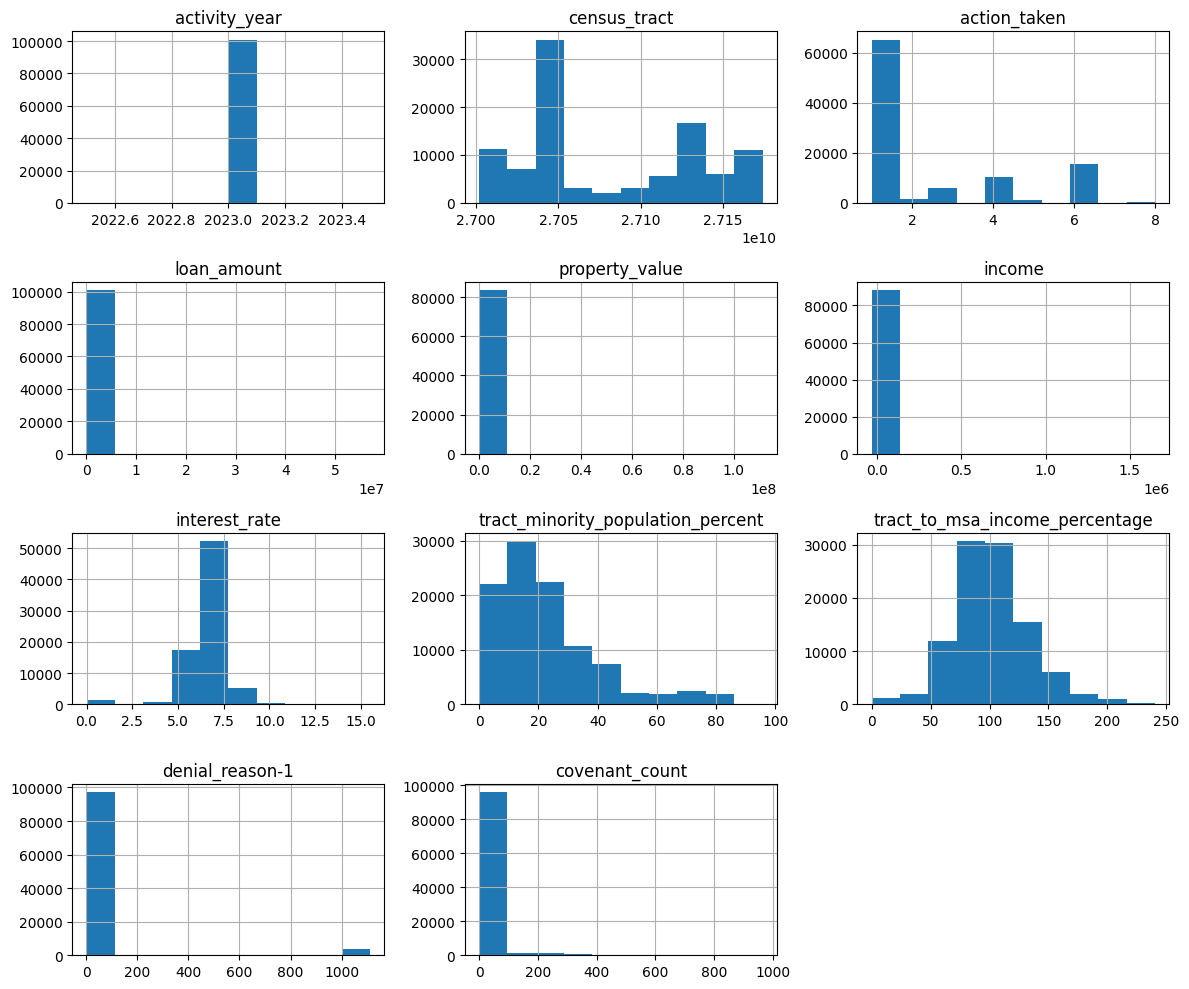

In [8]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

lets do a corellation matric graph

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

ValueError: could not convert string to float: 'Race Not Available'

<Figure size 1000x800 with 0 Axes>

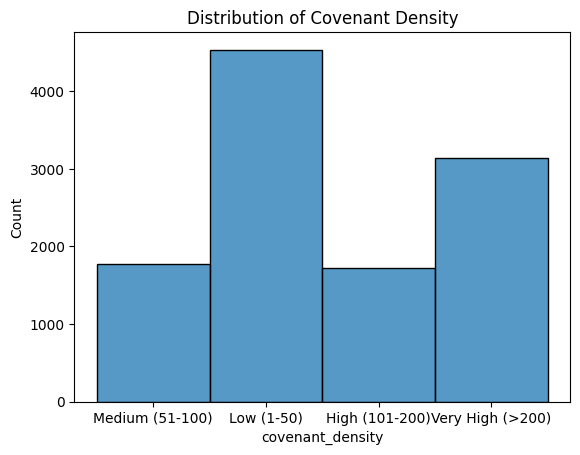

In [10]:
sns.histplot(df['covenant_density'], bins=30)

plt.title("Distribution of Covenant Density")
plt.show()

we have some null values and we have some errors and i need to fix some issues lets do that

first le me fix the datatype convertion error

In [11]:
df['covenant_density'] = pd.to_numeric(df['covenant_density'], errors='coerce')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

yup we have converted the datatypes and lets remove all the null values

In [13]:
df_clean = df.dropna(subset=['covenant_density'])

df_clean.shape

(0, 14)

lets me write code for the correlation matrix

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


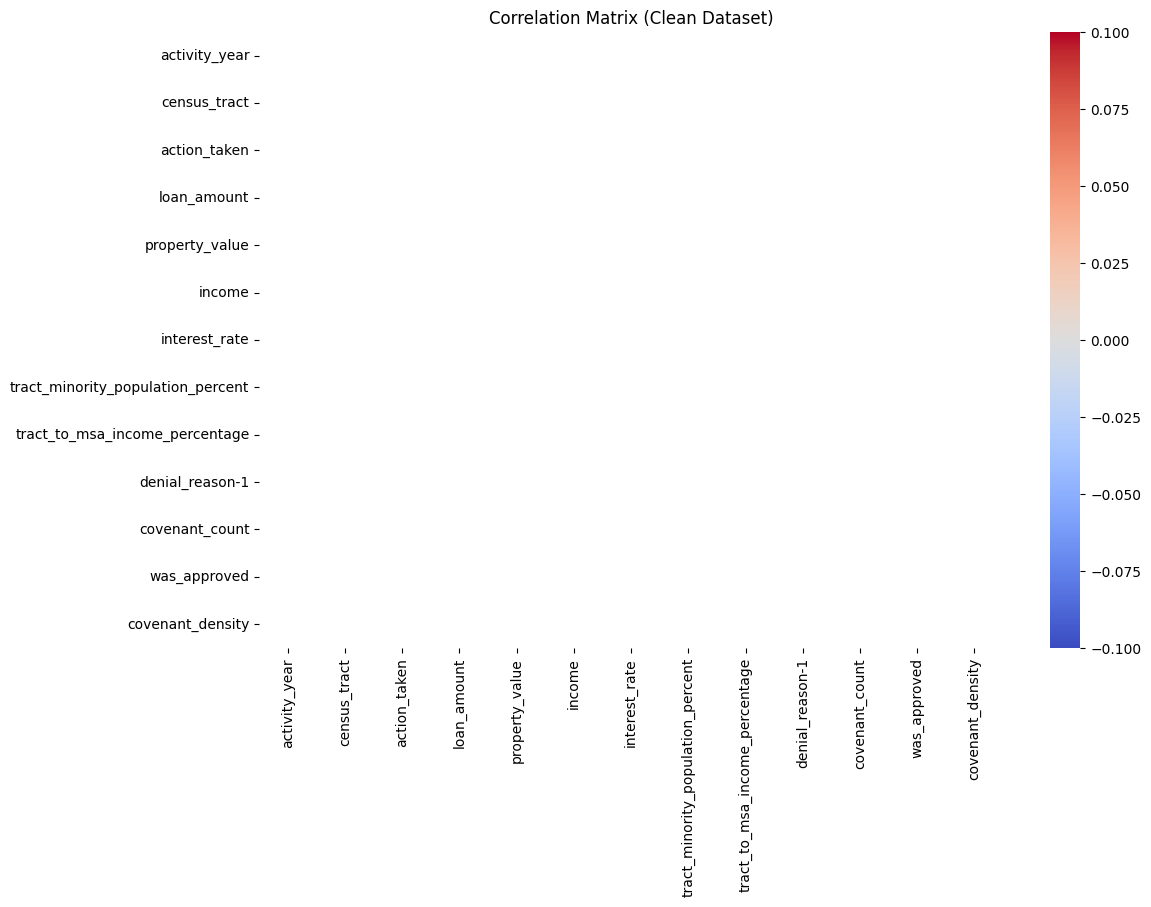

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(df_clean.corr(numeric_only=True),cmap="coolwarm",annot=True)

plt.title("Correlation Matrix (Clean Dataset)")
plt.show()